In [1]:
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from cartbctx import DecisionTreeClassifierBCTX

random_state = 1

In [2]:
def plot_pair_splits(
        tree: DecisionTreeClassifierBCTX,
        X = None, y = None, ax = None,
        line_color: str = 'k',
        line_width: float = 1.0,
        line_style: str = 'solid'
    ):
    plt.rcParams.update({'font.size': 12})
    
    if ax is None:
        _, ax = plt.subplots(figsize=(3,1.5))
        
    if X is not None and y is not None:
        sns.scatterplot(
            x=X.iloc[:, 0], y=X.iloc[:, 1],
            hue=y, palette="Set1", style=y,
            markers={1:"o", 2:"s", 3:"^"}, ax=ax
        )
        ax.legend_.remove()

    tree.plot_2d_splits(
        0, 1, [-2.5, -4], [11, 8],
        line_color=line_color,
        line_width=line_width,
        line_style=line_style,
        ax=ax
    )
    
    return ax

In [3]:
# synthetic data
rng = np.random.RandomState(random_state)
n1, n2, n3 = 50, 100, 50
X = np.concatenate([
    rng.randn(n1, 2),
    rng.randn(n2, 2) + np.array([[3.5, 2]]*n2),
    rng.randn(n3, 2) + np.array([[7, 5]]*n3)
], axis=0)
y = np.concatenate([
    np.full(n1, 1, dtype=object),
    np.full(n2, 2, dtype=object),
    np.full(n3, 3, dtype=object)
], axis=0)
X = pd.DataFrame(X, columns=['x1', 'x2'])
y = pd.Series(y)

In [4]:
X_trn_old, X_tmp, y_trn_old, y_tmp = train_test_split(
    X, y, train_size=(n1+n2+n3)//2,
    random_state=random_state
)
X_trn_new = X.copy()
y_trn_new = y.copy()

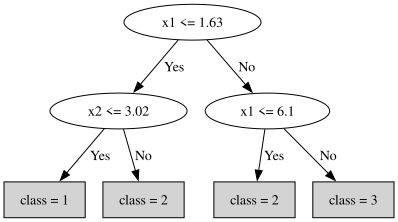

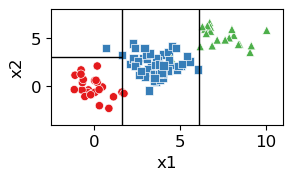

In [5]:
clf = DecisionTreeClassifierBCTX(max_depth=2)
clf.fit(X_trn_old, y_trn_old)
dot = clf.export_graphviz(report_n_samples=False, report_class_distribution=False, round_digits=2)
dot.render('old-tree', format='png', cleanup=True)
display(dot)
ax = plot_pair_splits(clf, X_trn_old, y_trn_old)
plt.savefig('old-splits.png', bbox_inches='tight')
plt.show()

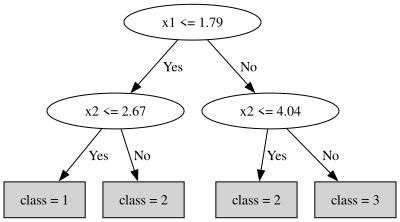

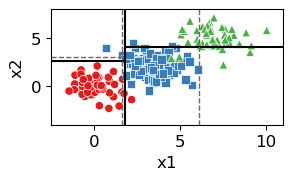

In [6]:
clf0 = copy.deepcopy(clf)
clf0.set_params(bctx_lambda=0.0)
clf0.fit(X_trn_new, y_trn_new)
dot0 = clf0.export_graphviz(report_n_samples=False, report_class_distribution=False, round_digits=2)
dot0.render('new-tree-naive', format='png', cleanup=True)
display(dot0)
ax = plot_pair_splits(clf0, X_trn_new, y_trn_new, line_width=1.5)
ax = plot_pair_splits(clf, line_color='dimgray', line_style='dashed', ax=ax)
plt.savefig('new-splits-naive.png', bbox_inches='tight')
plt.show()

BCTX mode: JAC


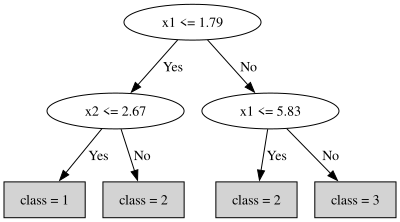

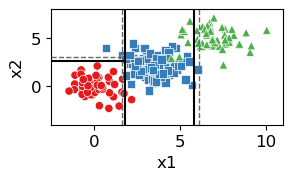

BCTX mode: JLU


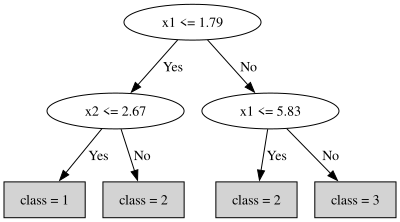

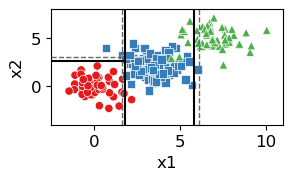

BCTX mode: MAE


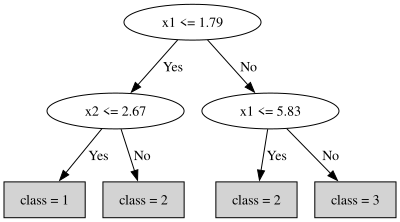

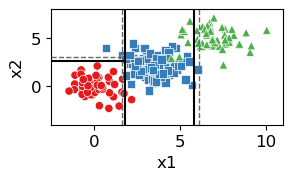

BCTX mode: MSE


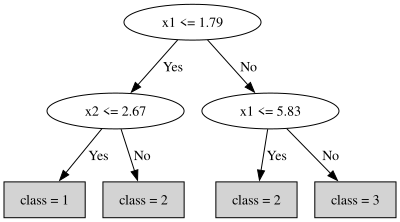

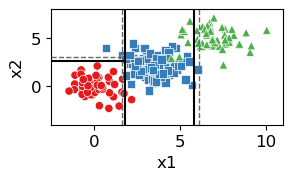

In [7]:
for bctx_str, bctx_mode in [('JAC',1), ('JLU',2), ('MAE',3), ('MSE',4)]:
    print(f'BCTX mode: {bctx_str}')
    clf1 = copy.deepcopy(clf)
    clf1.set_params(bctx_lambda=0.05, bctx_mode=bctx_mode)
    clf1.update(X_trn_new, y_trn_new)
    dot1 = clf1.export_graphviz(report_n_samples=False, report_class_distribution=False, round_digits=2)
    dot1.render(f'new-tree-bctx-{bctx_str}', format='png', cleanup=True)
    display(dot1)
    ax = plot_pair_splits(clf1, X_trn_new, y_trn_new, line_width=1.5)
    ax = plot_pair_splits(clf, line_color='dimgray', line_style='dashed', ax=ax)
    plt.savefig(f'new-splits-bctx-{bctx_str}.png', bbox_inches='tight')
    plt.show()